## Introduction
### Ce projet vise à développer un système intelligent capable de détecter les incohérences entre une interface conçue dans Figma et son implémentation en code.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model selection
from sklearn.model_selection import train_test_split, learning_curve

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/zakariakarkouch/figma-to-code/ai_qa_dataset_generated.csv")


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Afficher les 5 premières lignes
print("Aperçu du dataset :")
display(df.head())

# Informations générales
print("\n Informations :")
df.info()

# Statistiques descriptives
print("\n Statistiques :")
display(df.describe())

# Vérification valeurs manquantes
print("\n Valeurs nulles :")
print(df.isnull().sum())

# Vérification doublons
print("\n Doublons :")
print(df.duplicated().sum())

Aperçu du dataset :


,component,figma_color,code_color,figma_spacing,code_spacing,figma_font_size,code_font_size,figma_font_weight,code_font_weight,figma_border_radius,code_border_radius,figma_width,code_width,figma_height,code_height,mismatch_count,similarity_score,match
0,input,#72d6ed,#72d6ed,11,11,14,14,medium,medium,12,12,144,144,200,200,0,1.00,1
1,navbar,#3411c9,#3411c9,4,4,11,11,normal,normal,18,18,178,178,158,158,0,1.00,1
2,button,#159f07,#159f07,27,27,19,19,bold,bold,19,19,117,117,188,188,0,1.00,1
3,input,#83aee7,#678c4c,6,16,11,8,normal,normal,17,16,368,334,41,24,6,0.57,0
4,card,#6b49aa,#6b49aa,14,14,24,24,bold,bold,15,15,399,399,172,172,0,1.00,1



 Informations :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   component            8000 non-null   object 
 1   figma_color          8000 non-null   object 
 2   code_color           8000 non-null   object 
 3   figma_spacing        8000 non-null   int64  
 4   code_spacing         8000 non-null   int64  
 5   figma_font_size      8000 non-null   int64  
 6   code_font_size       8000 non-null   int64  
 7   figma_font_weight    8000 non-null   object 
 8   code_font_weight     8000 non-null   object 
 9   figma_border_radius  8000 non-null   int64  
 10  code_border_radius   8000 non-null   int64  
 11  figma_width          8000 non-null   int64  
 12  code_width           8000 non-null   int64  
 13  figma_height         8000 non-null   int64  
 14  code_height          8000 non-null   int64  
 15  mismatch_count       

,figma_spacing,code_spacing,figma_font_size,code_font_size,figma_border_radius,code_border_radius,figma_width,code_width,figma_height,code_height,mismatch_count,similarity_score,match
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,18.003625,18.009500,16.982875,16.982500,10.08525,10.093625,249.862500,250.022125,114.854875,114.877125,3.246125,0.797532,0.492875
std,8.296443,9.399426,4.364855,4.727234,6.04343,6.443877,86.946497,90.058520,49.015402,53.553431,3.236952,0.234282,0.499980
min,4.000000,-6.000000,10.000000,6.000000,0.00000,-5.000000,100.000000,53.000000,30.000000,-18.000000,0.000000,0.300000,0.000000
25%,11.000000,11.000000,13.000000,13.000000,5.00000,5.000000,175.000000,174.000000,73.000000,72.000000,0.000000,0.600000,0.000000
50%,18.000000,18.000000,17.000000,17.000000,10.00000,10.000000,250.500000,250.000000,115.000000,115.000000,5.000000,0.890000,0.000000
75%,25.000000,25.000000,21.000000,21.000000,15.00000,15.000000,325.000000,325.000000,157.000000,158.000000,7.000000,1.000000,1.000000
max,32.000000,42.000000,24.000000,28.000000,20.00000,25.000000,400.000000,445.000000,200.000000,249.000000,7.000000,1.000000,1.000000



 Valeurs nulles :
component              0
figma_color            0
code_color             0
figma_spacing          0
code_spacing           0
figma_font_size        0
code_font_size         0
figma_font_weight      0
code_font_weight       0
figma_border_radius    0
code_border_radius     0
figma_width            0
code_width             0
figma_height           0
code_height            0
mismatch_count         0
similarity_score       0
match                  0
dtype: int64

 Doublons :
0


In [5]:
df['figma_font_weight'].value_counts()
df['code_font_weight'].value_counts()

code_font_weight
bold      2727
medium    2679
normal    2594
Name: count, dtype: int64

In [6]:
mapping = {
    "normal": 0,
    "medium": 1,
    "bold": 2
}

df['code_font_weight'] = df['code_font_weight'].map(mapping)
df['figma_font_weight'] = df['figma_font_weight'].map(mapping)
df['figma_font_weight'].value_counts()
df['code_font_weight'].value_counts()

code_font_weight
2    2727
1    2679
0    2594
Name: count, dtype: int64

In [7]:
#1.Convert HEX → RGB
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return int(hex_color[0:2],16), int(hex_color[2:4],16), int(hex_color[4:6],16)

df[['figma_r','figma_g','figma_b']] = df['figma_color'].apply(lambda x: pd.Series(hex_to_rgb(x)))
df[['code_r','code_g','code_b']] = df['code_color'].apply(lambda x: pd.Series(hex_to_rgb(x)))


In [8]:
#2.Encode catégories
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['component'] = le.fit_transform(df['component'])
'''
df['figma_font_weight'] = le.fit_transform(df['figma_font_weight'])
df['code_font_weight'] = le.fit_transform(df['code_font_weight'])'''

"\ndf['figma_font_weight'] = le.fit_transform(df['figma_font_weight'])\ndf['code_font_weight'] = le.fit_transform(df['code_font_weight'])"

In [9]:
df['color_diff'] = abs(df['figma_r'] - df['code_r']) + \
                   abs(df['figma_g'] - df['code_g']) + \
                   abs(df['figma_b'] - df['code_b'])

df['spacing_diff'] = abs(df['figma_spacing'] - df['code_spacing'])
df['font_size_diff'] = abs(df['figma_font_size'] - df['code_font_size'])
df['width_diff'] = abs(df['figma_width'] - df['code_width'])
df['height_diff'] = abs(df['figma_height'] - df['code_height'])

In [10]:
df = df.drop(columns=['figma_color', 'code_color'])

In [11]:
df.head()

,component,figma_spacing,code_spacing,figma_font_size,code_font_size,figma_font_weight,code_font_weight,figma_border_radius,code_border_radius,figma_width,...,figma_g,figma_b,code_r,code_g,code_b,color_diff,spacing_diff,font_size_diff,width_diff,height_diff
0,2,11,11,14,14,1,1,12,12,144,...,214,237,114,214,237,0,0,0,0,0
1,3,4,4,11,11,0,0,18,18,178,...,17,201,52,17,201,0,0,0,0,0
2,0,27,27,19,19,2,2,19,19,117,...,159,7,21,159,7,0,0,0,0,0
3,2,6,16,11,8,0,0,17,16,368,...,174,231,103,140,76,217,10,3,34,17
4,1,14,14,24,24,2,2,15,15,399,...,73,170,107,73,170,0,0,0,0,0


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [13]:
#Features / Target
X = df.drop(columns=[
    'match',
    'similarity_score',  
    'mismatch_count'
])
feature_names = X.columns.tolist()

In [14]:
y = df['match']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
print("X_train (avant scaling) :")
display(pd.DataFrame(X_train).head())

print("\n X_test (avant scaling) :")
display(pd.DataFrame(X_test).head())

X_train (avant scaling) :


,component,figma_spacing,code_spacing,figma_font_size,code_font_size,figma_font_weight,code_font_weight,figma_border_radius,code_border_radius,figma_width,...,figma_g,figma_b,code_r,code_g,code_b,color_diff,spacing_diff,font_size_diff,width_diff,height_diff
1467,1,9,6,21,18,0,2,19,19,149,...,230,230,36,85,101,475,3,3,16,8
5768,2,15,15,21,21,2,2,17,17,114,...,124,152,170,124,152,0,0,0,0,0
5714,2,27,25,21,25,2,2,0,0,278,...,145,234,89,202,253,169,2,4,16,19
1578,4,5,5,21,21,2,2,1,1,105,...,98,58,19,98,58,0,0,0,0,0
6958,4,20,20,18,18,2,2,17,17,282,...,0,156,191,0,156,0,0,0,0,0



 X_test (avant scaling) :


,component,figma_spacing,code_spacing,figma_font_size,code_font_size,figma_font_weight,code_font_weight,figma_border_radius,code_border_radius,figma_width,...,figma_g,figma_b,code_r,code_g,code_b,color_diff,spacing_diff,font_size_diff,width_diff,height_diff
2215,0,28,28,18,18,0,0,9,9,183,...,255,37,167,255,37,0,0,0,0,0
2582,4,29,29,12,12,2,2,15,15,373,...,181,140,85,181,140,0,0,0,0,0
1662,3,27,27,16,16,1,1,0,0,347,...,148,241,1,148,241,0,0,0,0,0
3027,3,28,33,17,19,1,2,20,15,169,...,219,142,217,49,225,343,5,2,27,37
4343,4,6,6,13,13,2,2,7,7,252,...,245,66,95,245,66,0,0,0,0,0


In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   
X_test = scaler.transform(X_test)

In [18]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (6400, 24)
Test shape: (1600, 24)


In [19]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)
pd.set_option('display.max_columns', None)
print("X_train (après scaling) :")
display(X_train_df.head())

print("\n X_test (après scaling) :")
display(X_test_df.head())

X_train (après scaling) :


,component,figma_spacing,code_spacing,figma_font_size,code_font_size,figma_font_weight,code_font_weight,figma_border_radius,code_border_radius,figma_width,code_width,figma_height,code_height,figma_r,figma_g,figma_b,code_r,code_g,code_b,color_diff,spacing_diff,font_size_diff,width_diff,height_diff
0,-0.718328,-1.089079,-1.280132,0.926718,0.221443,-1.246583,1.219385,1.480983,1.390118,-1.158122,-1.298395,0.427515,0.539080,1.485048,1.348441,1.378402,-1.242571,-0.579110,-0.364756,2.320171,0.114662,1.312563,0.204402,-0.284390
1,-0.012896,-0.367399,-0.323533,0.926718,0.855741,1.224191,1.219385,1.149354,1.078662,-1.560315,-1.509480,1.695307,1.549191,0.577659,-0.073985,0.316943,0.580990,-0.057465,0.333412,-0.877268,-0.775919,-0.769321,-0.777988,-0.775693
2,-0.012896,1.075961,0.739355,0.926718,1.701471,1.224191,1.219385,-1.669494,-1.568719,0.324247,0.134761,-1.474172,-0.994793,0.740176,0.207816,1.432835,-0.521312,0.985826,1.716058,0.260347,-0.182198,2.006524,0.204402,0.391152
3,1.397967,-1.570198,-1.386421,0.926718,0.855741,1.224191,1.219385,-1.503679,-1.412991,-1.663736,-1.609468,-0.145036,-0.134328,-1.467353,-0.422882,-0.962251,-1.473918,-0.405228,-0.953408,-0.877268,-0.775919,-0.769321,-0.777988,-0.775693
4,1.397967,0.234001,0.207911,0.237655,0.221443,1.224191,1.219385,1.149354,1.078662,0.370211,0.356956,0.509308,0.464257,0.862064,-1.737956,0.371377,0.866772,-1.716029,0.388170,-0.877268,-0.775919,-0.769321,-0.777988,-0.775693



 X_test (après scaling) :


,component,figma_spacing,code_spacing,figma_font_size,code_font_size,figma_font_weight,code_font_weight,figma_border_radius,code_border_radius,figma_width,code_width,figma_height,code_height,figma_r,figma_g,figma_b,code_r,code_g,code_b,color_diff,spacing_diff,font_size_diff,width_diff,height_diff
0,-1.423760,1.196240,1.058221,0.237655,0.221443,-1.246583,-1.245575,-0.177163,-0.167165,-0.767420,-0.742908,-0.513104,-0.471032,0.537029,1.683919,-1.248028,0.540164,1.694728,-1.240889,-0.877268,-0.775919,-0.769321,-0.777988,-0.775693
1,1.397967,1.316520,1.164510,-1.140471,-1.047153,1.224191,1.219385,0.817725,0.767205,1.415913,1.367942,-1.351483,-1.237968,-0.573507,0.690904,0.153641,-0.575746,0.704940,0.169137,-0.877268,-0.775919,-0.769321,-0.777988,-0.775693
2,0.692536,1.075961,0.951932,-0.221720,-0.201423,-0.011196,-0.013095,-1.669494,-1.568719,1.117141,1.079089,1.490825,1.362134,-1.711129,0.248073,1.528094,-1.718874,0.263548,1.551783,-0.877268,-0.775919,-0.769321,-0.777988,-0.775693
3,0.692536,1.196240,1.589665,0.007967,0.432875,-0.011196,1.219385,1.646798,0.767205,-0.928297,-0.598482,-0.533552,-1.181851,-0.004696,1.200831,0.180858,1.220597,-1.060629,1.332750,1.431619,0.708383,0.618601,0.879796,1.496585
4,1.397967,-1.449918,-1.280132,-0.910783,-0.835721,1.224191,1.219385,-0.508792,-0.478621,0.025475,0.023664,0.059447,0.052730,-0.438076,1.549728,-0.853383,-0.439660,1.560973,-0.843891,-0.877268,-0.775919,-0.769321,-0.777988,-0.775693


In [20]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(len(cm)):
        for j in range(len(cm[0])):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()


def plot_learning(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Train")
    plt.plot(train_sizes, test_mean, label="Validation")

    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()

    plt.show()

Logistic Regression
Accuracy: 1.0


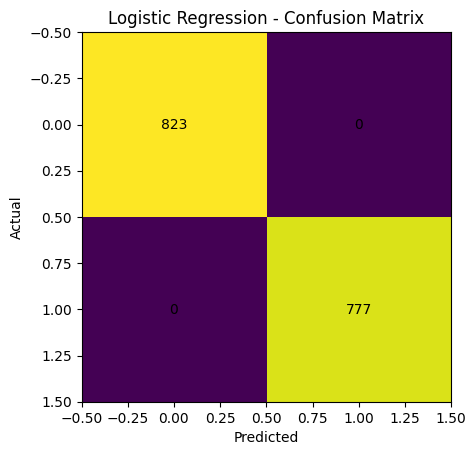

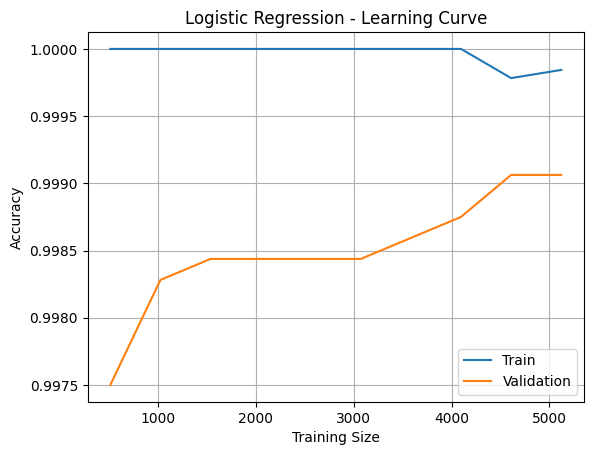

In [21]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

plot_confusion(y_test, y_pred_lr, "Logistic Regression - Confusion Matrix")
plot_learning(model_lr, X_train, y_train, "Logistic Regression - Learning Curve")

Random Forest
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       823
           1       1.00      1.00      1.00       777

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



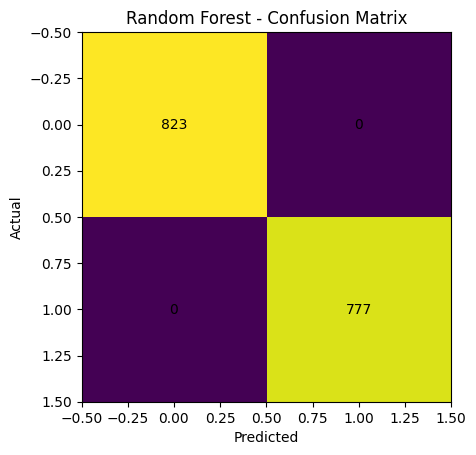

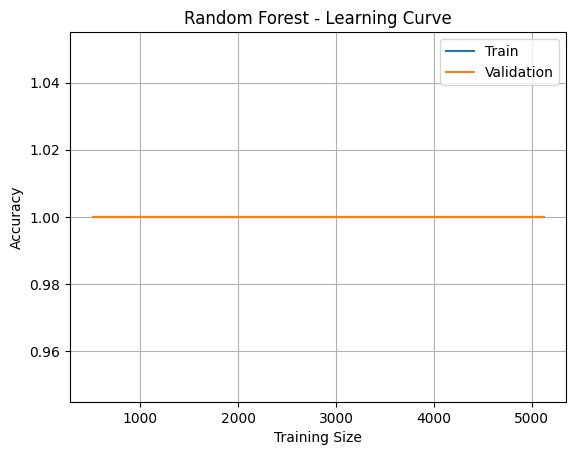

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialisation
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entraînement
model_rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = model_rf.predict(X_test)

# Évaluation
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
plot_confusion(y_test, y_pred_rf, "Random Forest - Confusion Matrix")

# Learning Curve
plot_learning(model_rf, X_train, y_train, "Random Forest - Learning Curve")

SVM
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       823
           1       1.00      1.00      1.00       777

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



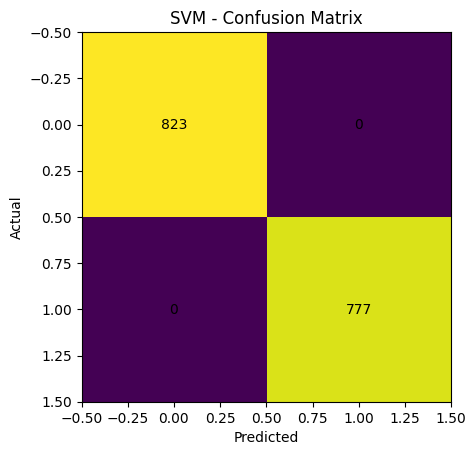

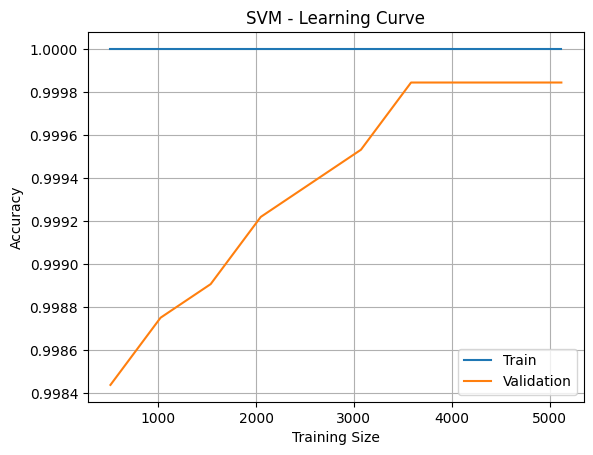

In [23]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialisation
model_svm = SVC(kernel='rbf')  # kernel non-linéaire

# Entraînement
model_svm.fit(X_train, y_train)

# Prédictions
y_pred_svm = model_svm.predict(X_test)

# Évaluation
print("SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

# Confusion Matrix
plot_confusion(y_test, y_pred_svm, "SVM - Confusion Matrix")

# Learning Curve
plot_learning(model_svm, X_train, y_train, "SVM - Learning Curve")

KNN
Accuracy: 0.983125

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98       823
           1       0.97      1.00      0.98       777

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



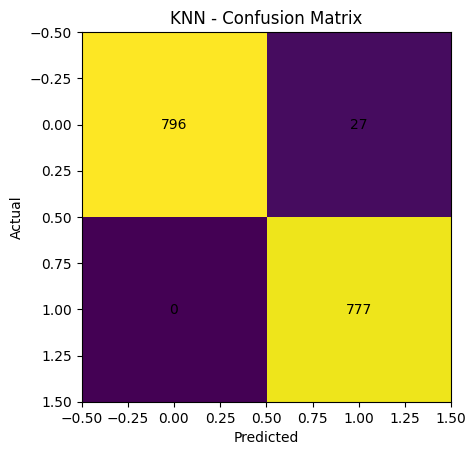

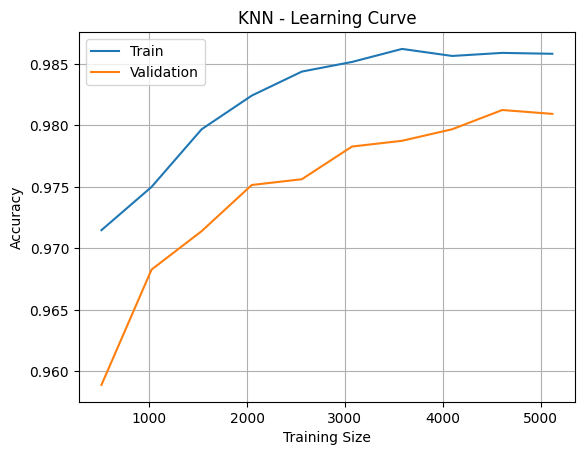

In [24]:
from sklearn.neighbors import KNeighborsClassifier
# Initialisation
model_knn = KNeighborsClassifier(n_neighbors=5)

# Entraînement
model_knn.fit(X_train, y_train)

# Prédictions
y_pred_knn = model_knn.predict(X_test)

# Évaluation
print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

# Confusion Matrix
plot_confusion(y_test, y_pred_knn, "KNN - Confusion Matrix")

# Learning Curve
plot_learning(model_knn, X_train, y_train, "KNN - Learning Curve")

Random Forest OPTIMISÉ
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       823
           1       1.00      1.00      1.00       777

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



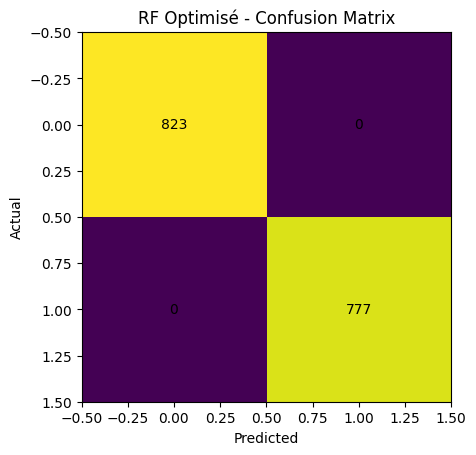

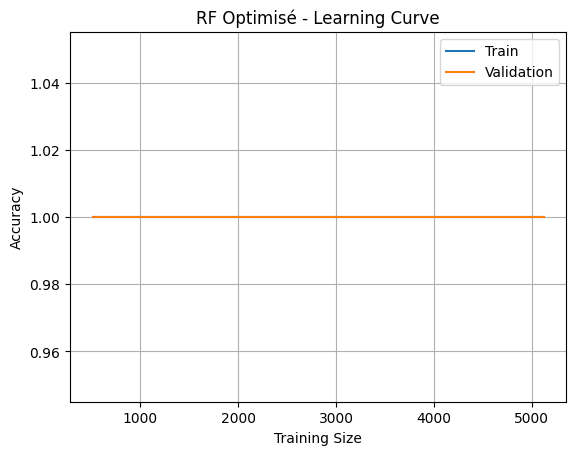

In [25]:

model_rf_opt = RandomForestClassifier(
    n_estimators=200,        # + arbres → plus stable
    max_depth=10,            # limite complexité → réduit overfitting
    min_samples_split=5,     # évite splits trop précis
    min_samples_leaf=2,      # évite feuilles trop petites
    class_weight='balanced', # important (corrige déséquilibre)
    random_state=42
)

# Train
model_rf_opt.fit(X_train, y_train)

# Predict
y_pred_rf_opt = model_rf_opt.predict(X_test)

# Evaluation
print("Random Forest OPTIMISÉ")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_opt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_opt))

# Confusion matrix
plot_confusion(y_test, y_pred_rf_opt, "RF Optimisé - Confusion Matrix")

# Learning curve
plot_learning(model_rf_opt, X_train, y_train, "RF Optimisé - Learning Curve")

XGBoost
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       823
           1       1.00      1.00      1.00       777

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



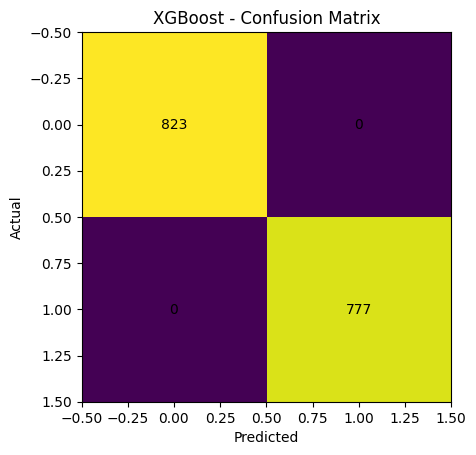

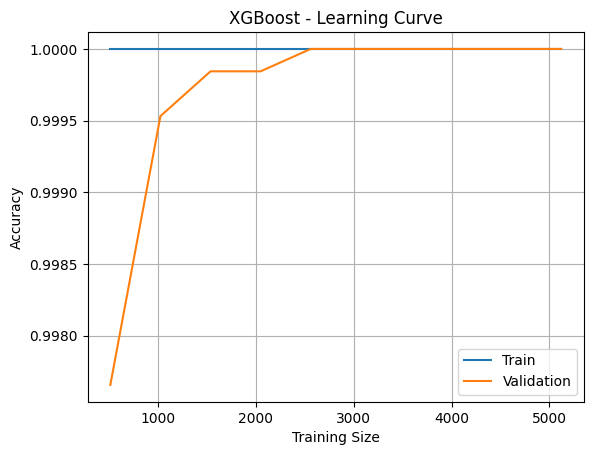

In [26]:
from xgboost import XGBClassifier
# Model
model_xgb = XGBClassifier(
    n_estimators=200,        # nombre d’arbres
    max_depth=6,             # profondeur (moins que RF → plus contrôlé)
    learning_rate=0.1,       # vitesse d’apprentissage
    subsample=0.7,           # fraction des données (réduit overfitting)
    colsample_bytree=0.6,    # fraction des features
    scale_pos_weight=1,      # à ajuster si déséquilibre
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train
model_xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = model_xgb.predict(X_test)

# Evaluation
print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# Confusion matrix
plot_confusion(y_test, y_pred_xgb, "XGBoost - Confusion Matrix")

# Learning curve
plot_learning(model_xgb, X_train, y_train, "XGBoost - Learning Curve")

LightGBM
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       823
           1       1.00      1.00      1.00       777

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



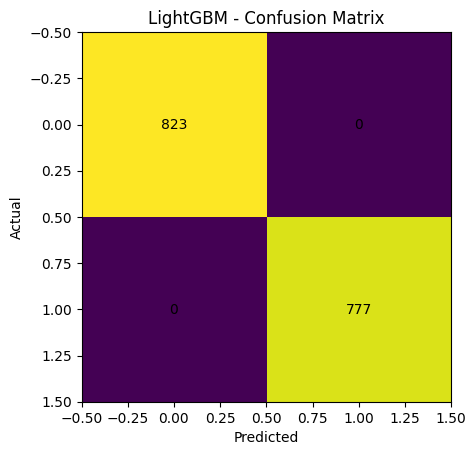

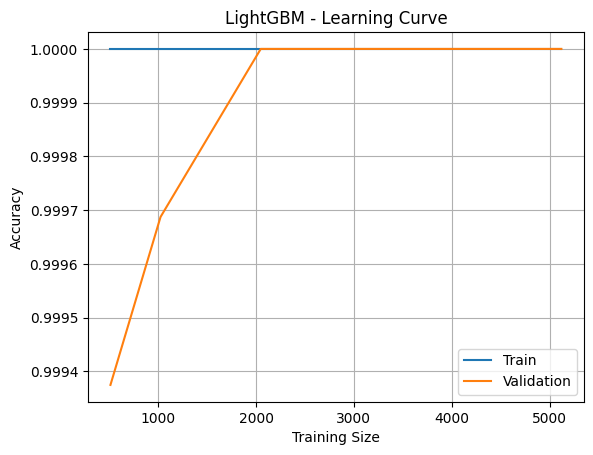

In [27]:
from lightgbm import LGBMClassifier

model_lgb = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.5,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

# Train
model_lgb.fit(X_train, y_train)

# Predict
y_pred_lgb = model_lgb.predict(X_test)

# Evaluation
print("LightGBM")
print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgb))

plot_confusion(y_test, y_pred_lgb, "LightGBM - Confusion Matrix")
plot_learning(model_lgb, X_train, y_train, "LightGBM - Learning Curve")

XGBoost OPTIMISÉ
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       823
           1       1.00      1.00      1.00       777

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



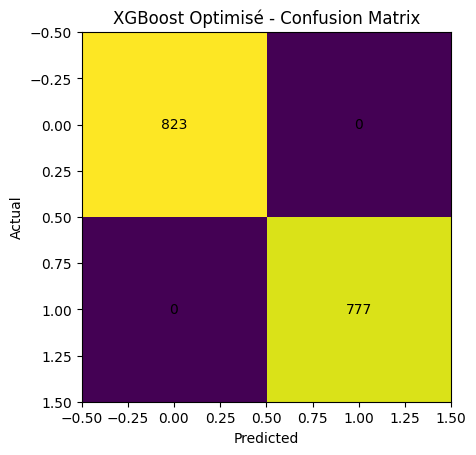

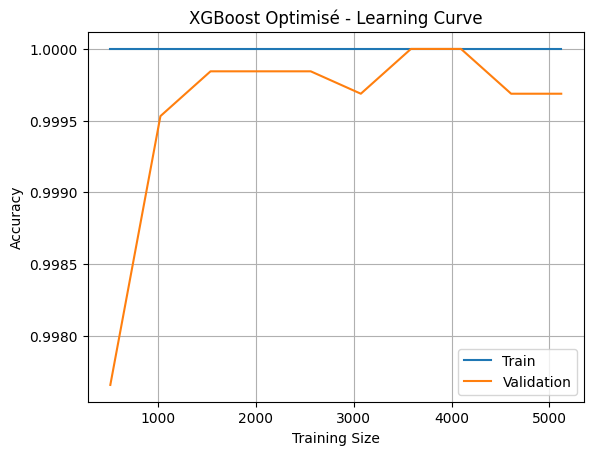

In [28]:
### from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# calcul ratio (IMPORTANT pour déséquilibre)
ratio = (y_train == 0).sum() / (y_train == 1).sum()
# Model optimisé
model_xgb_opt = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.7,  
    reg_alpha=1,
    reg_lambda=2,
    random_state=42,
    eval_metric='logloss'
)
# Train
model_xgb_opt.fit(X_train, y_train)

# Predict
y_pred_xgb_opt = model_xgb_opt.predict(X_test)

# Evaluation
print("XGBoost OPTIMISÉ")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_opt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_opt))

# Confusion matrix
plot_confusion(y_test, y_pred_xgb_opt, "XGBoost Optimisé - Confusion Matrix")

# Learning curve
plot_learning(model_xgb_opt, X_train, y_train, "XGBoost Optimisé - Learning Curve")

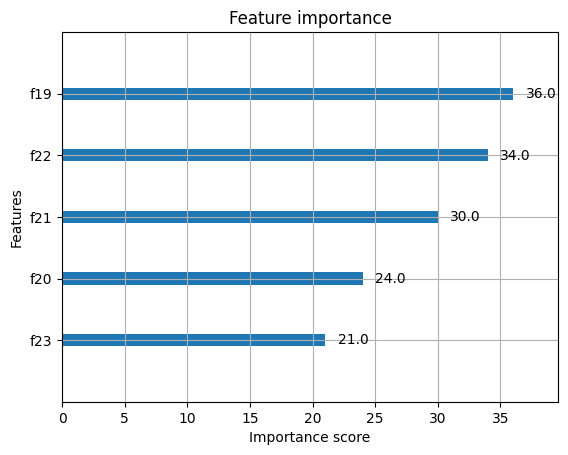

In [29]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model_xgb_opt)
plt.show()

In [30]:
import joblib

joblib.dump(model_xgb_opt, "model_xgb.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_names, "features.pkl")

['features.pkl']